# Day 67 - Why Random Forest Works So Well

## Bias-Variance Tradeoff

### Bias
- Bias refers to the error due to overly simplistic assumptions in the model
- A high bias model:
  - Fails to capture patterns in training data
  - Leads to underfitting

---

### Variance
- Variance refers to the model's sensitivity to small changes in input data
- A high variance model:
  - Performs very well on training data
  - Performs poorly on unseen data
  - Leads to overfitting

---

## Goal

- We want a model with:
  - Low Bias  
  - Low Variance  

- However, bias and variance are generally **inversely related**

---

## Examples

### Low Bias, High Variance Models
- Fully grown Decision Trees  
- K-Nearest Neighbors (small k)  
- Support Vector Machines (in some cases)  

---

### High Bias, Low Variance Models
- Linear Regression  

---

## Role of Random Forest

- Random Forest uses:
  - Multiple **fully grown decision trees** (low bias, high variance)
  - Combined using **Bagging (Bootstrap + Aggregation)**

---

## How Random Forest Reduces Variance

### Key Idea: Averaging Reduces Variance

- Each tree is trained on a **random subset of data**
- Noisy data points are:
  - Spread across different trees
  - Not concentrated in a single model

- It is highly unlikely that:
  - All noisy points affect all trees in the same way

---

### Effect

- Individual trees → High Variance  
- Combined model → Variance reduces significantly  

---

## Outcome

- Bias remains low (because trees are complex)
- Variance reduces (due to averaging multiple trees)

---

## Final Understanding

Random Forest transforms a:
- Low Bias + High Variance model (Decision Tree)

Into a:
- Low Bias + Low Variance model

---

## Summary

Random Forest works well because it reduces variance through bagging while maintaining low bias, resulting in a robust and highly accurate model.

## demo

In [1]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import matplotlib.pyplot as plt

In [8]:
np.random.seed(42)
# Generate synthetic dataset
X, y = make_circles(
    n_samples=500,
    factor=0.1,
    noise=0.35,
    random_state=42
)

In [9]:
X.shape

(500, 2)

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2
)

Text(0, 0.5, 'Feature 2')

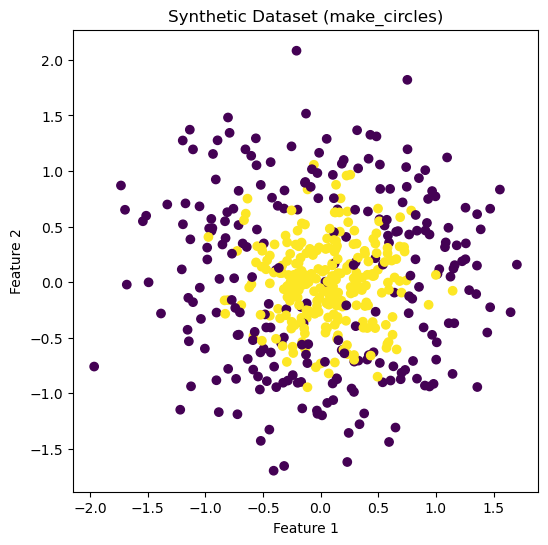

In [11]:
# Visualize the dataset
plt.figure(figsize=(6,6))
plt.scatter(X[:, 0], X[:, 1], c=y)

plt.title("Synthetic Dataset (make_circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

In [5]:
from sklearn.tree import DecisionTreeClassifier

In [12]:
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


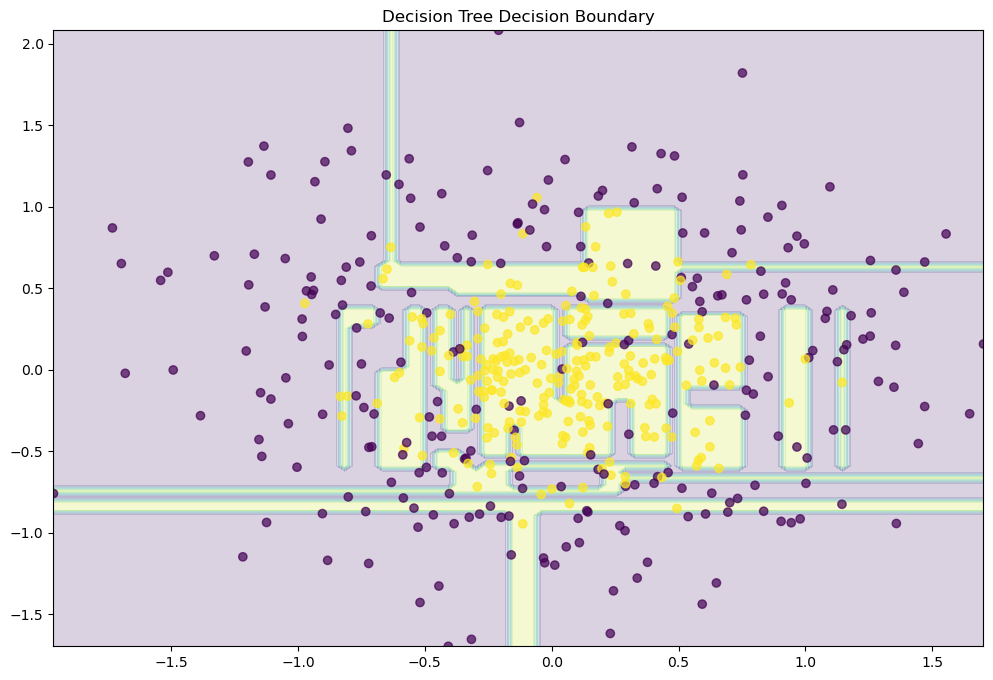

In [13]:
plt.figure(figsize=(12, 8))

x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 100)

xx1, xx2 = np.meshgrid(x1_range, x2_range)

y_hat = dtree.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)

plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)

plt.title("Decision Tree Decision Boundary")
plt.show()

>  as we can see clearly this is very overfiited model
-  high variance

##### now we are applying random forest on the dataset 

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


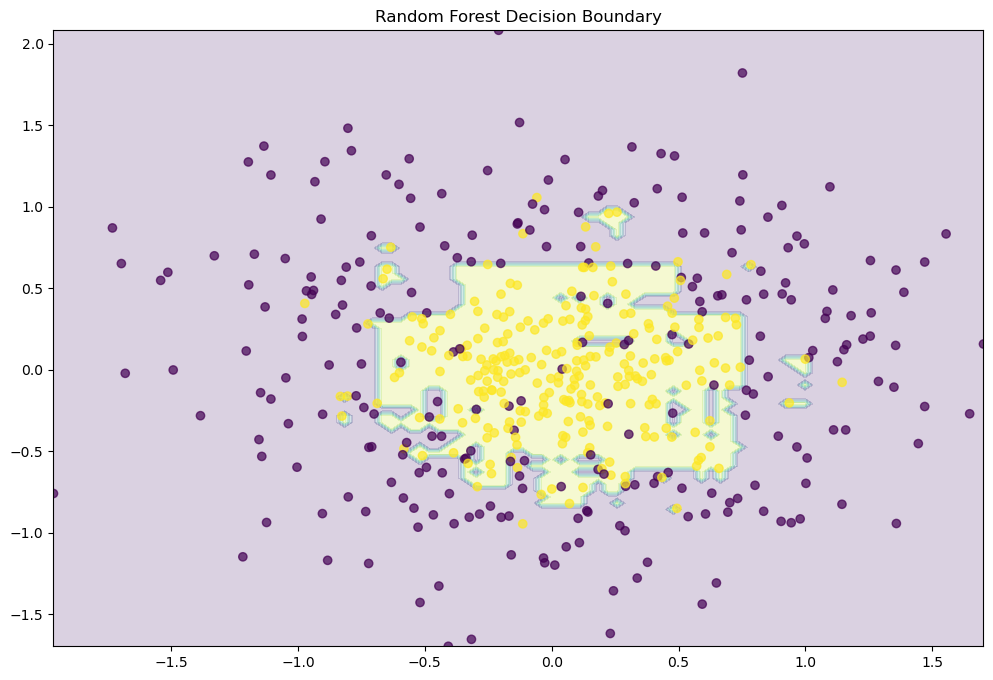

In [16]:
plt.figure(figsize=(12, 8))

# Create proper grid
x1_range = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2_range = np.linspace(X[:,1].min(), X[:,1].max(), 100)

xx1, xx2 = np.meshgrid(x1_range, x2_range)

# Predict on grid
y_hat = rf.predict(np.c_[xx1.ravel(), xx2.ravel()])
y_hat = y_hat.reshape(xx1.shape)

# Plot
plt.contourf(xx1, xx2, y_hat, alpha=0.2)
plt.scatter(X[:,0], X[:,1], c=y, cmap='viridis', alpha=0.7)

plt.title("Random Forest Decision Boundary")
plt.show()

> we can see the change that : a training error will increase a little bit : but the overall model is has low bais and low variance 

## Regression (Decision Tree vs Random Forest).

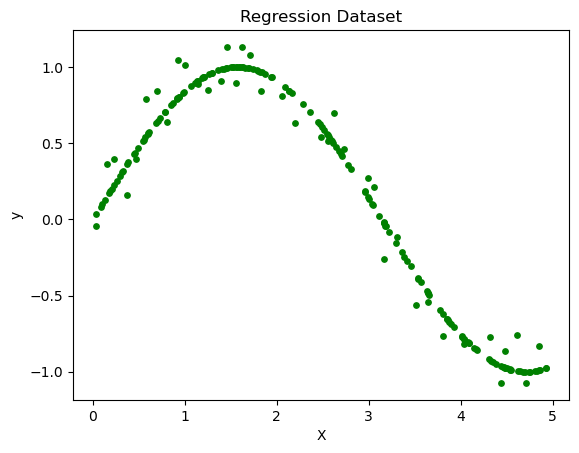

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Create synthetic regression data
np.random.seed(42)

X = np.sort(5 * np.random.rand(200, 1), axis=0)
y = np.sin(X).ravel()

#  noise
y[::5] += 0.5 * (0.5 - np.random.rand(40))


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


plt.scatter(X, y, color='green', s=15)
plt.title("Regression Dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [21]:
## random forest 
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
X_test_range = np.linspace(0, 5, 500).reshape(-1, 1)

y_dt = dt.predict(X_test_range)
y_rf = rf.predict(X_test_range)

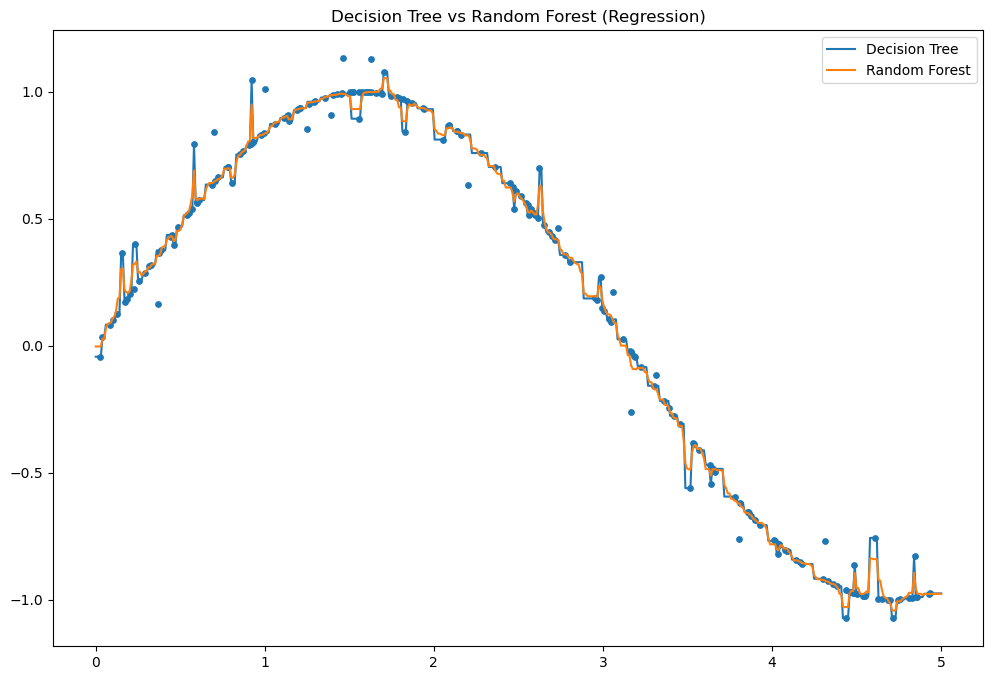

In [27]:
plt.figure(figsize=(12, 8))

# Original data
plt.scatter(X, y, s=15)

# Decision Tree prediction
plt.plot(X_test_range, y_dt, label="Decision Tree" )

# Random Forest prediction
plt.plot(X_test_range, y_rf, label="Random Forest")

plt.title("Decision Tree vs Random Forest (Regression)")
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import mean_squared_error


y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)


mse_dt = mean_squared_error(y_test, y_pred_dt)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("Decision Tree MSE:", mse_dt)
print("Random Forest MSE:", mse_rf)

Decision Tree MSE: 0.010289847286012958
Random Forest MSE: 0.008035881786399158
